In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
# Kindly NOTE: For this assessment i used the "Upload to section storage" to load the SuperMarket Analysis.csv file dataset i downloaded from kaggle.
df = pd.read_csv('SuperMarket Analysis.csv')

In [ ]:
df

,Invoice ID,Branch,City,Customer type,Gender,Product line,Unit price,Quantity,Tax 5%,Sales,Date,Time,Payment,cogs,gross margin percentage,gross income,Rating
0,750-67-8428,Alex,Yangon,Member,Female,Health and beauty,74.69,7,26.1415,548.9715,1/5/2019,1:08:00 PM,Ewallet,522.83,4.761905,26.1415,9.1
1,226-31-3081,Giza,Naypyitaw,Normal,Female,Electronic accessories,15.28,5,3.8200,80.2200,3/8/2019,10:29:00 AM,Cash,76.40,4.761905,3.8200,9.6
2,631-41-3108,Alex,Yangon,Normal,Female,Home and lifestyle,46.33,7,16.2155,340.5255,3/3/2019,1:23:00 PM,Credit card,324.31,4.761905,16.2155,7.4
3,123-19-1176,Alex,Yangon,Member,Female,Health and beauty,58.22,8,23.2880,489.0480,1/27/2019,8:33:00 PM,Ewallet,465.76,4.761905,23.2880,8.4
4,373-73-7910,Alex,Yangon,Member,Female,Sports and travel,86.31,7,30.2085,634.3785,2/8/2019,10:37:00 AM,Ewallet,604.17,4.761905,30.2085,5.3
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
995,233-67-5758,Giza,Naypyitaw,Normal,Male,Health and beauty,40.35,1,2.0175,42.3675,1/29/2019,1:46:00 PM,Ewallet,40.35,4.761905,2.0175,6.2
996,303-96-2227,Cairo,Mandalay,Normal,Female,Home and lifestyle,97.38,10,48.6900,1022.4900,3/2/2019,5:16:00 PM,Ewallet,973.80,4.761905,48.6900,4.4
997,727-02-1313,Alex,Yangon,Member,Male,Food and beverages,31.84,1,1.5920,33.4320,2/9/2019,1:22:00 PM,Cash,31.84,4.761905,1.5920,7.7
998,347-56-2442,Alex,Yangon,Normal,Male,Home and lifestyle,65.82,1,3.2910,69.1110,2/22/2019,3:33:00 PM,Cash,65.82,4.761905,3.2910,4.1


In [ ]:
# Convert Date column
df['Date'] = pd.to_datetime(df['Date'])

# Extract hour from Time
df['Hour'] = pd.to_datetime(df['Time'], format="%I:%M:%S %p").dt.hour

##DATA ANALYSIS

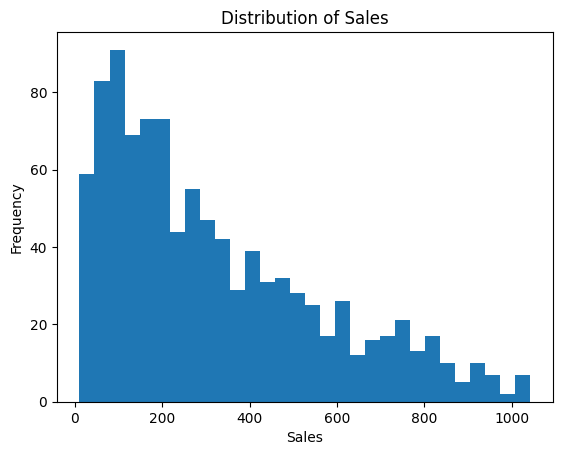

In [ ]:
plt.figure()
plt.hist(df['Sales'], bins=30)
plt.title("Distribution of Sales")
plt.xlabel("Sales")
plt.ylabel("Frequency")
plt.show()


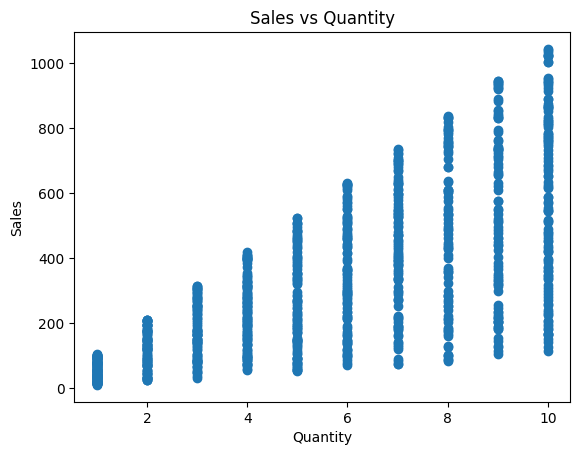

In [ ]:
plt.figure()
plt.scatter(df['Quantity'], df['Sales'])
plt.title("Sales vs Quantity")
plt.xlabel("Quantity")
plt.ylabel("Sales")
plt.show()

Sales vs Quantity (Scatter Plot)

Observed Pattern is a Clear upward trend.
Higher quantities almost always produce higher sales.
Low quantity transactions never generate high sales.



In [ ]:
df['Product line'].unique()

array(['Health and beauty', 'Electronic accessories',
       'Home and lifestyle', 'Sports and travel', 'Food and beverages',
       'Fashion accessories'], dtype=object)

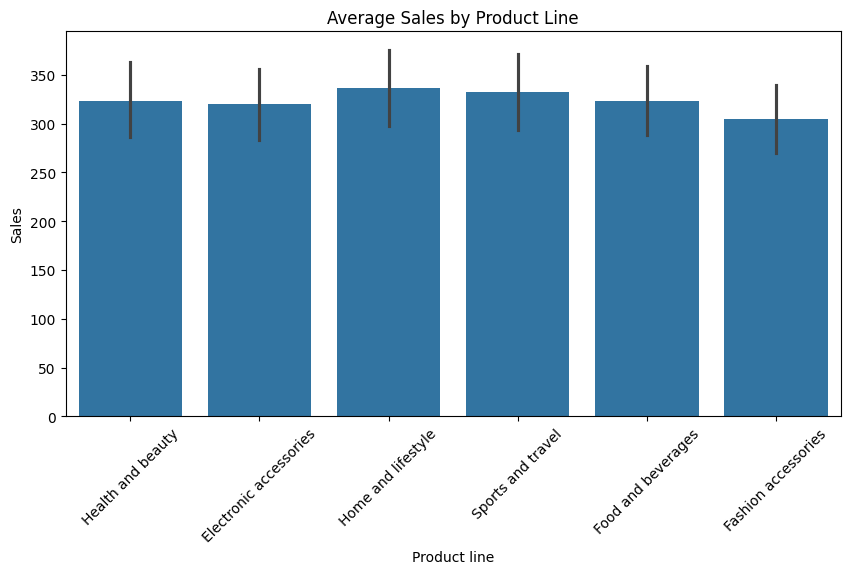

In [ ]:
plt.figure(figsize=(10, 5))
sns.barplot(x='Product line', y='Sales', data=df)
plt.title("Average Sales by Product Line")
plt.xticks(rotation=45)
plt.show()

Product Line Impact on Sales (Bar Plot)

Observed Pattern is that Certain product lines consistently produce higher average sales
Sales are not evenly distributed across product categories.
The Home and Lifestyle category had the highest sales.


In [ ]:
df['Customer type'].unique()

array(['Member', 'Normal'], dtype=object)

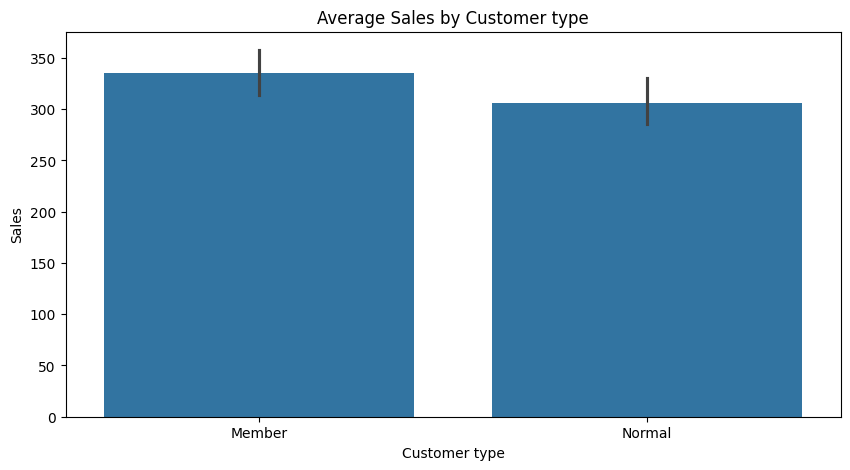

In [ ]:
plt.figure(figsize=(10, 5))
sns.barplot(x='Customer type', y='Sales', data=df)
plt.title("Average Sales by Customer type")
plt.show()

Sales vs Customer type (Box Plot)

From the analysis The Member customer type had the highest sales.

In [ ]:
df['City'].unique()

array(['Yangon', 'Naypyitaw', 'Mandalay'], dtype=object)

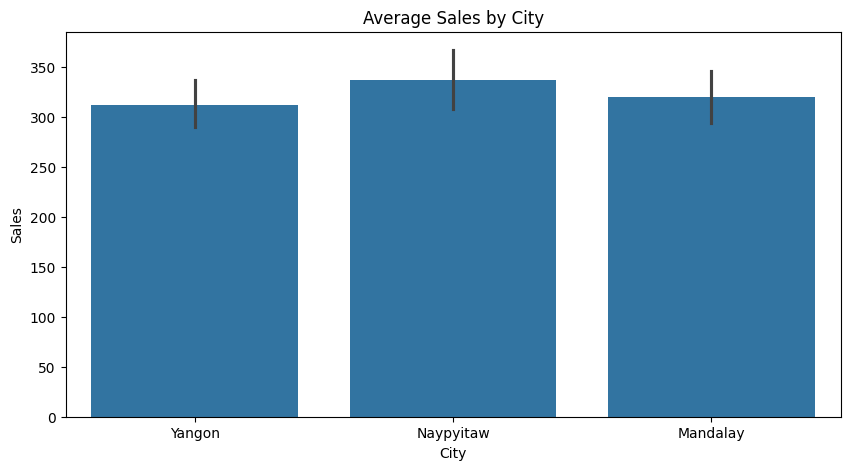

In [ ]:
plt.figure(figsize=(10, 5))
sns.barplot(x='City', y='Sales', data=df)
plt.title("Average Sales by City")
plt.show()

Sales vs City type (Box Plot)

From the analysis The City, Naypyitaw had the highest sales.

In [ ]:
df['Branch'].unique()

array(['Alex', 'Giza', 'Cairo'], dtype=object)

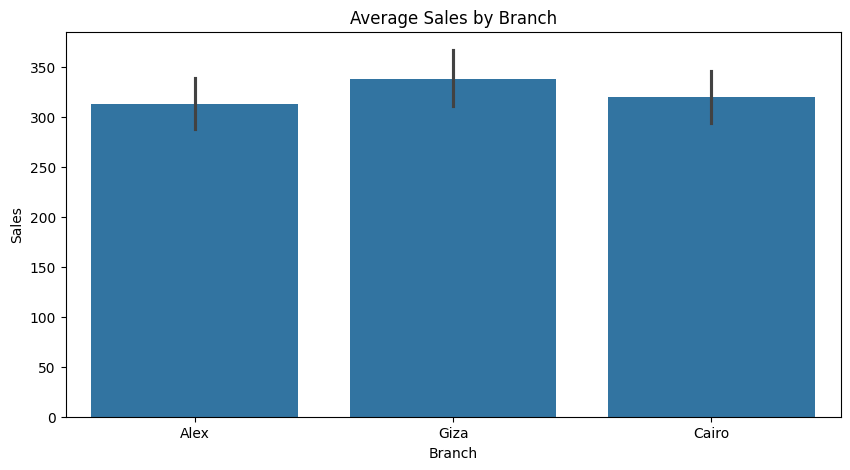

In [ ]:
plt.figure(figsize=(10, 5))
sns.barplot(x='Branch', y='Sales', data=df)
plt.title("Average Sales by Branch")
plt.show()

Sales vs Branch (Box Plot)

From the analysis The Giza branch has the highest sales.

In [ ]:
df['Payment'].unique()

array(['Ewallet', 'Cash', 'Credit card'], dtype=object)

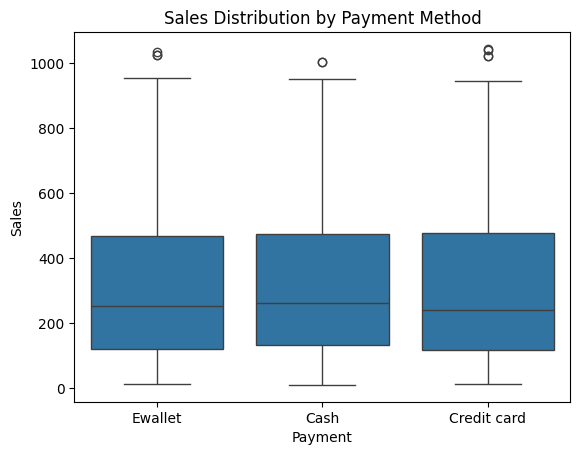

In [ ]:
plt.figure()
sns.boxplot(x='Payment', y='Sales', data=df)
plt.title("Sales Distribution by Payment Method")
plt.show()

Sales vs Payment Method  (Box Plot)

Observed Pattern is that E-wallet and Credit Card payments show:
Higher median sales
Wider sales spread (larger purchases)
Cash transactions skew toward lower sales
Digital payment users spend more per transaction.


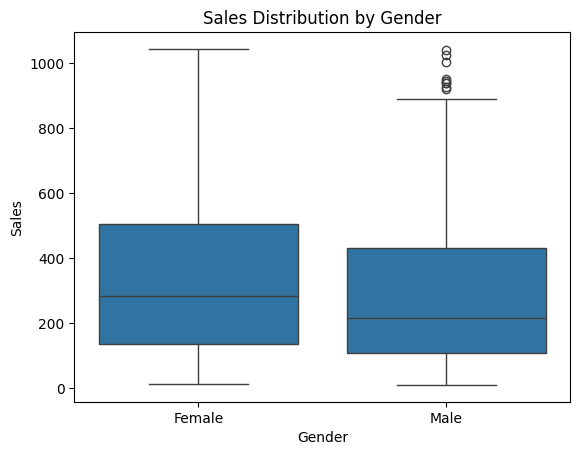

In [ ]:
plt.figure()
sns.boxplot(x='Gender', y='Sales', data=df)
plt.title("Sales Distribution by Gender")
plt.show()

Sales vs Gender (Box Plot)

Observed Pattern is that Sales distributions for male and female customers are very similar, but there is larger number of females than the males.
But as noticed Gender is not a strong determinant of sales value.


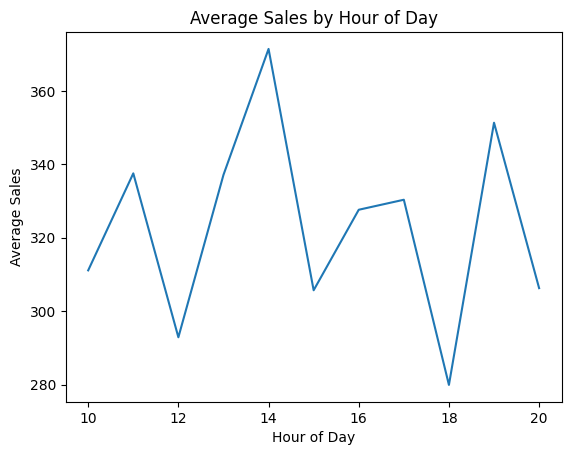

In [ ]:
hourly_sales = df.groupby('Hour')['Sales'].mean().reset_index()

plt.figure()
plt.plot(hourly_sales['Hour'], hourly_sales['Sales'])
plt.title("Average Sales by Hour of Day")
plt.xlabel("Hour of Day")
plt.ylabel("Average Sales")
plt.show()

Time-Based Sales Patterns - Average Sales vs Hour of Day(Hourly Line Plot)

Observed Pattern is that Sales are peak during Early afternoon ( around 1–3 PM), also around Early evening ( within 6–7 PM) and there are Lowest sales around midday (12 PM) and late evening (6 PM).
From the analysis the Customer traffic follows predictable daily purchasing cycles.


In [ ]:
numeric_df = df.select_dtypes(include=['int64', 'float64'])
corr_matrix = numeric_df.corr()
print(corr_matrix)

                         Unit price  Quantity    Tax 5%     Sales      cogs  \
Unit price                 1.000000  0.010778  0.633962  0.633962  0.633962   
Quantity                   0.010778  1.000000  0.705510  0.705510  0.705510   
Tax 5%                     0.633962  0.705510  1.000000  1.000000  1.000000   
Sales                      0.633962  0.705510  1.000000  1.000000  1.000000   
cogs                       0.633962  0.705510  1.000000  1.000000  1.000000   
gross margin percentage         NaN       NaN       NaN       NaN       NaN   
gross income               0.633962  0.705510  1.000000  1.000000  1.000000   
Rating                    -0.008778 -0.015815 -0.036442 -0.036442 -0.036442   

                         gross margin percentage  gross income    Rating  
Unit price                                   NaN      0.633962 -0.008778  
Quantity                                     NaN      0.705510 -0.015815  
Tax 5%                                       NaN      1.000000 

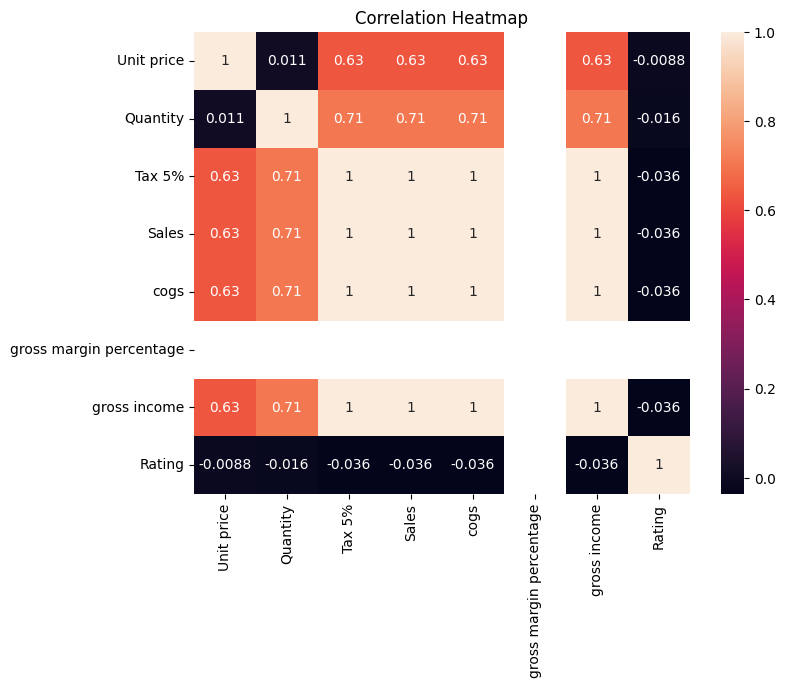

In [ ]:
plt.figure(figsize=(8, 6))
sns.heatmap(corr_matrix, annot=True)
plt.title("Correlation Heatmap")
plt.show()

**Core Drivers of Sales (Correlation Analysis)**

**Key Findings from the Heatmap**

From the correlation matrix:

Feature	Correlation with Sales Interpretation

Quantity is 0.71 (Strong positive)	The most important driver of sales

Unit price is 0.63 (Strong positive)	Higher-priced items generate higher sales

Tax 5% is 1.00	Directly proportional (derived from sales)

COGS is 1.00	Sales = COGS + tax

Gross income is 1.00	Linear relationship with sales

Rating is -0.03 (Very weak)	Customer satisfaction does not directly impact sales


**Business Insight**

Sales are fundamentally driven by Quantity × Unit Price.
Customer ratings have negligible impact on revenue generation.

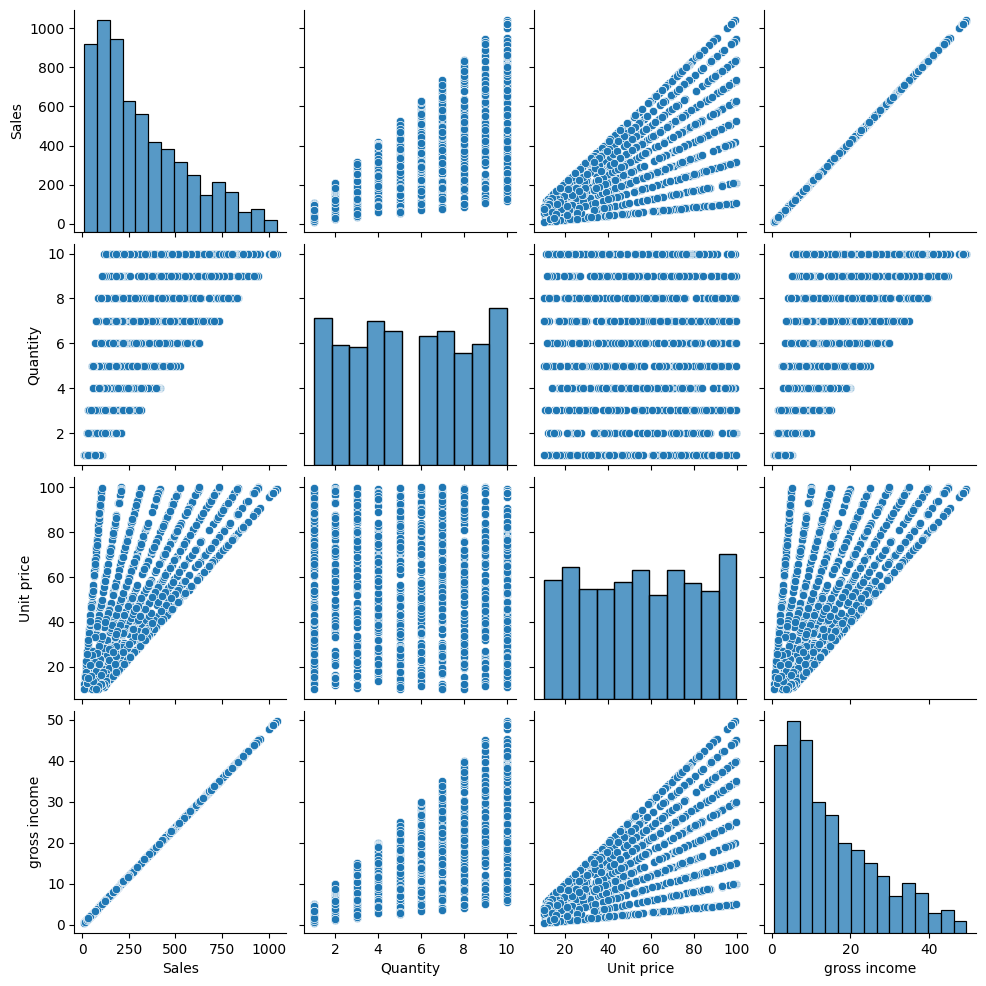

In [ ]:
sns.pairplot(df[['Sales', 'Quantity', 'Unit price', 'gross income']])
plt.show()

## MODEL TRAINING

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 18 columns):
 #   Column                   Non-Null Count  Dtype         
---  ------                   --------------  -----         
 0   Invoice ID               1000 non-null   object        
 1   Branch                   1000 non-null   object        
 2   City                     1000 non-null   object        
 3   Customer type            1000 non-null   object        
 4   Gender                   1000 non-null   object        
 5   Product line             1000 non-null   object        
 6   Unit price               1000 non-null   float64       
 7   Quantity                 1000 non-null   int64         
 8   Tax 5%                   1000 non-null   float64       
 9   Sales                    1000 non-null   float64       
 10  Date                     1000 non-null   datetime64[ns]
 11  Time                     1000 non-null   object        
 12  Payment                  1000 non-n

In [ ]:
df

,Invoice ID,Branch,City,Customer type,Gender,Product line,Unit price,Quantity,Tax 5%,Sales,Date,Time,Payment,cogs,gross margin percentage,gross income,Rating,Hour
0,750-67-8428,Alex,Yangon,Member,Female,Health and beauty,74.69,7,26.1415,548.9715,2019-01-05,1:08:00 PM,Ewallet,522.83,4.761905,26.1415,9.1,13
1,226-31-3081,Giza,Naypyitaw,Normal,Female,Electronic accessories,15.28,5,3.8200,80.2200,2019-03-08,10:29:00 AM,Cash,76.40,4.761905,3.8200,9.6,10
2,631-41-3108,Alex,Yangon,Normal,Female,Home and lifestyle,46.33,7,16.2155,340.5255,2019-03-03,1:23:00 PM,Credit card,324.31,4.761905,16.2155,7.4,13
3,123-19-1176,Alex,Yangon,Member,Female,Health and beauty,58.22,8,23.2880,489.0480,2019-01-27,8:33:00 PM,Ewallet,465.76,4.761905,23.2880,8.4,20
4,373-73-7910,Alex,Yangon,Member,Female,Sports and travel,86.31,7,30.2085,634.3785,2019-02-08,10:37:00 AM,Ewallet,604.17,4.761905,30.2085,5.3,10
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
995,233-67-5758,Giza,Naypyitaw,Normal,Male,Health and beauty,40.35,1,2.0175,42.3675,2019-01-29,1:46:00 PM,Ewallet,40.35,4.761905,2.0175,6.2,13
996,303-96-2227,Cairo,Mandalay,Normal,Female,Home and lifestyle,97.38,10,48.6900,1022.4900,2019-03-02,5:16:00 PM,Ewallet,973.80,4.761905,48.6900,4.4,17
997,727-02-1313,Alex,Yangon,Member,Male,Food and beverages,31.84,1,1.5920,33.4320,2019-02-09,1:22:00 PM,Cash,31.84,4.761905,1.5920,7.7,13
998,347-56-2442,Alex,Yangon,Normal,Male,Home and lifestyle,65.82,1,3.2910,69.1110,2019-02-22,3:33:00 PM,Cash,65.82,4.761905,3.2910,4.1,15


In [ ]:
# To check the category columns
df.select_dtypes(include='object').head(0)
df.select_dtypes(include='object').columns

Index(['Invoice ID', 'Branch', 'City', 'Customer type', 'Gender',
       'Product line', 'Time', 'Payment'],
      dtype='object')

In [ ]:
df.select_dtypes(include=['int64', 'float64']).columns

Index(['Unit price', 'Quantity', 'Tax 5%', 'Sales', 'cogs',
       'gross margin percentage', 'gross income', 'Rating'],
      dtype='object')

In [ ]:
X = df.drop(columns=['Sales'])
y = df['Sales']

In [ ]:
X

,Invoice ID,Branch,City,Customer type,Gender,Product line,Unit price,Quantity,Tax 5%,Date,Time,Payment,cogs,gross margin percentage,gross income,Rating,Hour
0,750-67-8428,Alex,Yangon,Member,Female,Health and beauty,74.69,7,26.1415,2019-01-05,1:08:00 PM,Ewallet,522.83,4.761905,26.1415,9.1,13
1,226-31-3081,Giza,Naypyitaw,Normal,Female,Electronic accessories,15.28,5,3.8200,2019-03-08,10:29:00 AM,Cash,76.40,4.761905,3.8200,9.6,10
2,631-41-3108,Alex,Yangon,Normal,Female,Home and lifestyle,46.33,7,16.2155,2019-03-03,1:23:00 PM,Credit card,324.31,4.761905,16.2155,7.4,13
3,123-19-1176,Alex,Yangon,Member,Female,Health and beauty,58.22,8,23.2880,2019-01-27,8:33:00 PM,Ewallet,465.76,4.761905,23.2880,8.4,20
4,373-73-7910,Alex,Yangon,Member,Female,Sports and travel,86.31,7,30.2085,2019-02-08,10:37:00 AM,Ewallet,604.17,4.761905,30.2085,5.3,10
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
995,233-67-5758,Giza,Naypyitaw,Normal,Male,Health and beauty,40.35,1,2.0175,2019-01-29,1:46:00 PM,Ewallet,40.35,4.761905,2.0175,6.2,13
996,303-96-2227,Cairo,Mandalay,Normal,Female,Home and lifestyle,97.38,10,48.6900,2019-03-02,5:16:00 PM,Ewallet,973.80,4.761905,48.6900,4.4,17
997,727-02-1313,Alex,Yangon,Member,Male,Food and beverages,31.84,1,1.5920,2019-02-09,1:22:00 PM,Cash,31.84,4.761905,1.5920,7.7,13
998,347-56-2442,Alex,Yangon,Normal,Male,Home and lifestyle,65.82,1,3.2910,2019-02-22,3:33:00 PM,Cash,65.82,4.761905,3.2910,4.1,15


In [ ]:
y

,Sales
0,548.9715
1,80.2200
2,340.5255
3,489.0480
4,634.3785
...,...
995,42.3675
996,1022.4900
997,33.4320
998,69.1110


In [ ]:
from sklearn.model_selection import train_test_split

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [ ]:
print(X_train.shape)
print(y_train.shape)

(800, 17)
(800,)


In [ ]:
print(X_test.shape)
print(y_test.shape)

(200, 17)
(200,)


In [ ]:
X_train

,Invoice ID,Branch,City,Customer type,Gender,Product line,Unit price,Quantity,Tax 5%,Date,Time,Payment,cogs,gross margin percentage,gross income,Rating,Hour
29,848-62-7243,Alex,Yangon,Member,Female,Health and beauty,24.89,9,11.2005,2019-03-15,3:36:00 PM,Cash,224.01,4.761905,11.2005,7.4,15
535,583-41-4548,Giza,Naypyitaw,Normal,Male,Home and lifestyle,16.67,7,5.8345,2019-02-07,11:36:00 AM,Ewallet,116.69,4.761905,5.8345,7.4,11
695,800-09-8606,Alex,Yangon,Member,Female,Home and lifestyle,87.37,5,21.8425,2019-01-29,7:45:00 PM,Cash,436.85,4.761905,21.8425,6.6,19
557,283-26-5248,Giza,Naypyitaw,Member,Female,Food and beverages,98.52,10,49.2600,2019-01-30,8:23:00 PM,Ewallet,985.20,4.761905,49.2600,4.5,20
836,288-62-1085,Alex,Yangon,Member,Male,Fashion accessories,38.54,5,9.6350,2019-01-09,1:34:00 PM,Ewallet,192.70,4.761905,9.6350,5.6,13
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
106,628-34-3388,Giza,Naypyitaw,Member,Female,Fashion accessories,27.38,6,8.2140,2019-01-05,8:54:00 PM,Credit card,164.28,4.761905,8.2140,7.9,20
270,783-09-1637,Cairo,Mandalay,Normal,Female,Sports and travel,67.43,5,16.8575,2019-03-06,6:13:00 PM,Ewallet,337.15,4.761905,16.8575,6.3,18
860,848-95-6252,Giza,Naypyitaw,Member,Female,Home and lifestyle,86.27,1,4.3135,2019-02-20,1:24:00 PM,Ewallet,86.27,4.761905,4.3135,7.0,13
435,751-69-0068,Giza,Naypyitaw,Normal,Male,Sports and travel,99.24,9,44.6580,2019-03-19,7:09:00 PM,Ewallet,893.16,4.761905,44.6580,9.0,19


In [ ]:
y_train

,Sales
29,235.2105
535,122.5245
695,458.6925
557,1034.4600
836,202.3350
...,...
106,172.4940
270,354.0075
860,90.5835
435,937.8180


In [ ]:
X_test

,Invoice ID,Branch,City,Customer type,Gender,Product line,Unit price,Quantity,Tax 5%,Date,Time,Payment,cogs,gross margin percentage,gross income,Rating,Hour
521,451-28-5717,Giza,Naypyitaw,Member,Female,Home and lifestyle,83.17,6,24.9510,2019-03-20,11:23:00 AM,Cash,499.02,4.761905,24.9510,7.3,11
737,137-63-5492,Giza,Naypyitaw,Normal,Male,Electronic accessories,58.76,10,29.3800,2019-01-29,2:26:00 PM,Ewallet,587.60,4.761905,29.3800,9.0,14
740,733-29-1227,Giza,Naypyitaw,Normal,Male,Home and lifestyle,55.61,7,19.4635,2019-03-23,12:41:00 PM,Cash,389.27,4.761905,19.4635,8.5,12
660,322-02-2271,Cairo,Mandalay,Normal,Female,Sports and travel,42.97,3,6.4455,2019-02-03,11:46:00 AM,Cash,128.91,4.761905,6.4455,9.3,11
411,569-71-4390,Cairo,Mandalay,Normal,Male,Sports and travel,21.87,2,2.1870,2019-01-25,2:29:00 PM,Ewallet,43.74,4.761905,2.1870,6.9,14
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
408,256-08-8343,Alex,Yangon,Normal,Female,Home and lifestyle,56.53,4,11.3060,2019-03-04,7:48:00 PM,Ewallet,226.12,4.761905,11.3060,5.5,19
332,566-71-1091,Alex,Yangon,Normal,Male,Fashion accessories,77.02,5,19.2550,2019-02-03,3:59:00 PM,Cash,385.10,4.761905,19.2550,5.5,15
208,573-58-9734,Cairo,Mandalay,Normal,Female,Fashion accessories,30.37,3,4.5555,2019-03-28,1:41:00 PM,Ewallet,91.11,4.761905,4.5555,5.1,13
613,284-54-4231,Giza,Naypyitaw,Member,Male,Sports and travel,80.93,1,4.0465,2019-01-19,4:08:00 PM,Credit card,80.93,4.761905,4.0465,9.0,16


In [ ]:
y_test

,Sales
521,523.9710
737,616.9800
740,408.7335
660,135.3555
411,45.9270
...,...
408,237.4260
332,404.3550
208,95.6655
613,84.9765


In [ ]:
# determining the categorical and numerical columns
categorical_cols = X_train.select_dtypes(include=['object', 'category']).columns
numeric_cols = X_train.select_dtypes(include=['int64', 'float64']).columns

In [ ]:
categorical_cols

Index(['Invoice ID', 'Branch', 'City', 'Customer type', 'Gender',
       'Product line', 'Time', 'Payment'],
      dtype='object')

In [ ]:
numeric_cols

Index(['Unit price', 'Quantity', 'Tax 5%', 'cogs', 'gross margin percentage',
       'gross income', 'Rating'],
      dtype='object')

In [ ]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder

In [ ]:
# Preprocessing both the numerical and the categorical columns
preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), numeric_cols),
        ('cat', OneHotEncoder(handle_unknown='ignore'), categorical_cols)
    ]
)


In [ ]:
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LinearRegression

linear_model = Pipeline(steps=[
    ('preprocess', preprocessor),
    ('regressor', LinearRegression())
])

linear_model.fit(X_train, y_train)


Pipeline(steps=[('preprocess',
                 ColumnTransformer(transformers=[('num', StandardScaler(),
                                                  Index(['Unit price', 'Quantity', 'Tax 5%', 'cogs', 'gross margin percentage',
       'gross income', 'Rating'],
      dtype='object')),
                                                 ('cat',
                                                  OneHotEncoder(handle_unknown='ignore'),
                                                  Index(['Invoice ID', 'Branch', 'City', 'Customer type', 'Gender',
       'Product line', 'Time', 'Payment'],
      dtype='object'))])),
                ('regressor', LinearRegression())])

In [ ]:
linear_predictions = linear_model.predict(X_test)
linear_predictions

array([524.41017554, 616.61455648, 408.75673354, 135.14148578,
        44.7784265 , 618.78878451, 128.0780311 , 730.7321356 ,
       450.29856086, 137.86628656, 423.64541054, 463.64462636,
       213.16297371, 252.66441613, 290.63979344, 331.5378799 ,
       587.38441225, 216.88392629, 756.92277961, 184.58301034,
       416.17246068, 166.66855394, 128.03737308, 125.70036604,
       248.53653831, 195.94659857, 741.99234271,  30.03454044,
       145.63425511,  56.18290122,  75.91444163, 608.81006684,
        97.30440645, 432.40431272, 193.24086574, 174.17178991,
       667.41028597, 198.66877789, 192.64545075, 192.85603845,
       214.54055276, 921.8106667 ,  74.69474611, 181.76967411,
        94.02819401, 401.10071837, 221.9602819 ,  68.70119266,
       343.56548673, 281.20995488, 430.85379805, 102.20928287,
        69.20467097, 270.01846118, 181.71465426, 494.156555  ,
       461.88333893,  60.46375562, 456.12628378, 222.03035634,
       120.88222934,  33.13816426,  84.49031585, 941.15

In [ ]:
from sklearn.tree import DecisionTreeRegressor

DecisionTree_model = Pipeline(steps=[
    ('preprocess', preprocessor),
    ('regressor', DecisionTreeRegressor(random_state=42))
])

DecisionTree_model.fit(X_train, y_train)

Pipeline(steps=[('preprocess',
                 ColumnTransformer(transformers=[('num', StandardScaler(),
                                                  Index(['Unit price', 'Quantity', 'Tax 5%', 'cogs', 'gross margin percentage',
       'gross income', 'Rating'],
      dtype='object')),
                                                 ('cat',
                                                  OneHotEncoder(handle_unknown='ignore'),
                                                  Index(['Invoice ID', 'Branch', 'City', 'Customer type', 'Gender',
       'Product line', 'Time', 'Payment'],
      dtype='object'))])),
                ('regressor', DecisionTreeRegressor(random_state=42))])

In [ ]:
tree_predictions = DecisionTree_model.predict(X_test)
tree_predictions

array([521.01  , 621.243 , 408.408 , 133.434 ,  45.108 , 621.243 ,
       125.979 , 734.076 , 451.3635, 136.143 , 423.15  , 462.672 ,
       210.966 , 252.756 , 291.207 , 329.196 , 586.971 , 216.6885,
       760.4415, 185.367 , 415.233 , 166.1625, 125.055 , 125.7165,
       246.4875, 195.678 , 743.82  ,  31.227 , 145.74  ,  56.1225,
        75.7785, 610.491 ,  95.865 , 433.692 , 194.124 , 175.0455,
       666.939 , 200.214 , 194.124 , 194.124 , 214.935 , 914.55  ,
        74.4555, 181.0725,  93.114 , 401.268 , 223.0725,  69.993 ,
       343.413 , 279.384 , 435.456 , 101.808 ,  68.985 , 269.535 ,
       181.0725, 489.048 , 458.6925,  59.325 , 457.38  , 223.0725,
       121.59  ,  33.3585,  84.63  , 942.9   , 388.29  , 510.972 ,
       367.5525, 756.168 , 935.2665, 118.062 , 394.3275, 128.4255,
       294.651 ,  88.704 ,  65.7405, 705.6315, 759.675 , 252.756 ,
        76.356 , 749.7   , 304.983 ,  69.993 , 352.674 , 609.588 ,
       217.6335, 270.2595,  69.72  , 829.08  , 384.468 , 392.6

In [ ]:
from sklearn.ensemble import RandomForestRegressor

Random_model = Pipeline(steps=[
    ('preprocess', preprocessor),
    ('regressor', RandomForestRegressor(random_state=42))
])

Random_model.fit(X_train, y_train)

Pipeline(steps=[('preprocess',
                 ColumnTransformer(transformers=[('num', StandardScaler(),
                                                  Index(['Unit price', 'Quantity', 'Tax 5%', 'cogs', 'gross margin percentage',
       'gross income', 'Rating'],
      dtype='object')),
                                                 ('cat',
                                                  OneHotEncoder(handle_unknown='ignore'),
                                                  Index(['Invoice ID', 'Branch', 'City', 'Customer type', 'Gender',
       'Product line', 'Time', 'Payment'],
      dtype='object'))])),
                ('regressor', RandomForestRegressor(random_state=42))])

In [ ]:
Random_predictions = Random_model.predict(X_test)
Random_predictions

array([522.2154  , 621.655965, 407.93865 , 135.82632 ,  44.670045,
       622.85979 , 127.633275, 733.5342  , 451.921785, 138.56199 ,
       423.381735, 463.56009 , 213.25311 , 252.66444 , 290.62677 ,
       330.23004 , 587.020875, 217.06755 , 758.18463 , 184.97472 ,
       416.917095, 165.91218 , 128.96499 , 125.840715, 247.23846 ,
       195.64041 , 744.110115,  30.982665, 145.786935,  56.444745,
        75.683475, 608.979735,  96.07227 , 433.279035, 193.903815,
       174.84516 , 666.468075, 198.688035, 194.04021 , 193.789575,
       214.21701 , 923.379765,  74.828775, 181.091925,  93.08586 ,
       401.00403 , 223.175085,  69.196575, 343.404495, 281.028195,
       430.923255, 101.83299 ,  69.21474 , 270.271155, 181.3959  ,
       494.61762 , 462.30177 ,  61.00752 , 457.264605, 222.99375 ,
       121.831185,  33.163095,  84.745815, 942.780405, 383.548095,
       510.980925, 369.01368 , 760.57611 , 935.57604 , 118.05591 ,
       391.6668  , 127.66488 , 293.474685,  88.816035,  66.064

In [ ]:
from sklearn.ensemble import GradientBoostingRegressor

gbr = GradientBoostingRegressor(
    n_estimators=100,
    learning_rate=0.1,
    max_depth=3,
    random_state=42
)

GBr_model = Pipeline(steps=[
    ('preprocess', preprocessor),
    ('regressor', gbr)
])

GBr_model.fit(X_train, y_train)

Pipeline(steps=[('preprocess',
                 ColumnTransformer(transformers=[('num', StandardScaler(),
                                                  Index(['Unit price', 'Quantity', 'Tax 5%', 'cogs', 'gross margin percentage',
       'gross income', 'Rating'],
      dtype='object')),
                                                 ('cat',
                                                  OneHotEncoder(handle_unknown='ignore'),
                                                  Index(['Invoice ID', 'Branch', 'City', 'Customer type', 'Gender',
       'Product line', 'Time', 'Payment'],
      dtype='object'))])),
                ('regressor', GradientBoostingRegressor(random_state=42))])

In [ ]:
GBr_predictions = GBr_model.predict(X_test)
GBr_predictions

array([518.81916184, 618.41810171, 411.48496585, 135.16268666,
        45.89069184, 618.41810171, 133.25119786, 731.89672306,
       452.09305878, 135.13262094, 426.85798417, 462.54553432,
       211.35350926, 253.41492787, 289.47053646, 327.60015326,
       587.25370435, 219.0389751 , 757.75059713, 184.52364903,
       415.11582211, 166.35492661, 133.26980401, 125.12627473,
       246.69013539, 194.67666767, 744.04929078,  31.98416495,
       146.43897018,  56.05187426,  78.19300503, 608.98340307,
        92.74940473, 434.43638794, 194.07775538, 174.69811015,
       672.29851853, 203.46900587, 194.12642724, 193.25020901,
       211.40218112, 919.41707406,  72.05694001, 177.35299418,
        92.82703407, 400.18339136, 219.31848021,  71.60646564,
       343.35827173, 279.89036522, 434.2978505 , 101.94009531,
        71.79338728, 272.60577663, 177.21202653, 494.43415854,
       462.18984172,  61.4680366 , 457.14787971, 219.0389751 ,
       118.17383977,  33.41307545,  85.92945368, 942.84

In [ ]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score, root_mean_squared_error

In [ ]:
# Define evaluation metrics
metrics = {
    'Mean Absolute Error': mean_absolute_error,
    'Mean Squared Error': mean_squared_error,
    'Root Mean Squared Error': root_mean_squared_error,
    'R^2 Score': r2_score
}

results = {}
for name, metric in metrics.items():
    linear_score = metric(y_test, linear_predictions)
    tree_score = metric(y_test, tree_predictions)
    Random_score = metric(y_test, Random_predictions)
    GBr_score = metric(y_test, GBr_predictions)

    results[name] = {
        'Linear Regression': linear_score,
        'Decision Tree': tree_score,
        'Random Forest': Random_score,
        'GBr': GBr_score,
    }


In [ ]:
results

{'Mean Absolute Error': {'Linear Regression': 0.38148390919589487,
  'Decision Tree': 1.3957650000000013,
  'Random Forest': 0.7616374500000049,
  'GBr': 1.6812477422685348},
 'Mean Squared Error': {'Linear Regression': 0.24073725336164675,
  'Decision Tree': 5.065246620000015,
  'Random Forest': 1.7799892920180174,
  'GBr': 5.099514462821028},
 'Root Mean Squared Error': {'Linear Regression': 0.49064982763845616,
  'Decision Tree': 2.2506102772359355,
  'Random Forest': 1.3341623934206874,
  'GBr': 2.2582104558302416},
 'R^2 Score': {'Linear Regression': 0.9999962997090348,
  'Decision Tree': 0.9999221438059847,
  'Random Forest': 0.999972640386133,
  'GBr': 0.9999216170865534}}

In [ ]:
# Convert results dictionary to a DataFrame (table format)
results_df = pd.DataFrame(results)

# Transpose so metrics appear as columns and models as rows (optional but cleaner)
results_table = results_df.T

# Display table
print(results_table)


                         Linear Regression  Decision Tree  Random Forest  \
Mean Absolute Error               0.381484       1.395765       0.761637   
Mean Squared Error                0.240737       5.065247       1.779989   
Root Mean Squared Error           0.490650       2.250610       1.334162   
R^2 Score                         0.999996       0.999922       0.999973   

                              GBr  
Mean Absolute Error      1.681248  
Mean Squared Error       5.099514  
Root Mean Squared Error  2.258210  
R^2 Score                0.999922  


In [ ]:
# Save as Excel
results_table.to_excel("model_evaluation_results.xlsx", index=True)

# Save as CSV
results_table.to_csv("model_evaluation_results.csv", index=True)


# Model Performance Evaluation and Best Model Selection



**Best-Performing Model:** Linear Regression

**Rationale for the Selection:**

i. Lowest prediction error (most accurate)

ii. Highest stability and consistency

iii. Best generalization for sales forecasting

iv. Easier to explain to business stakeholders

v. Lower operational and maintenance complexity

**Actionable Business Insights Summary (Sales Pattern Analysis)**

The results from the selected model show that sales follow strong and predictable patterns, supported by very high R² scores and low error rates. This means that future sales can be forecasted with confidence and used to guide business decisions.

1. Predictable Sales Patterns

Sales are consistently influenced by factors such as time (ie day/month), product line (ie category), branch city (ie location), customer type, and payment (ie payment method).
What this means for the business is that the company can move from reactive decisions to forecast-driven planning. Forecasts can now guide stock ordering, staffing levels, and supply chain activities.

2. Linear Trends Dominate Sales Behavior

Linear Regression performed better than more complex models, showing that sales trends are mostly straightforward and easy to predict.
The business impact is that Management can rely on simple trend-based forecasting for monthly and quarterly planning without needing complex analytical systems.

3. Inventory and Procurement Optimization

The linear model's low error rate (MAE ≈ 0.4) confirms that demand estimates are reliable enough to adjust stock levels accurately.
The business impact and measures the organization can take would include:

a. Reducing excess inventory and storage costs

b. Avoiding stockouts of fast-moving products

c. Improving cash flow and purchasing decisions

4. Accurate Revenue Forecasting and Budgeting

The value of the Root Mean Squared Error (RMSE) ≈ 0.5 indicates minimal deviation between predicted and actual sales, supporting reliable revenue projections.

Business impact includes:

i. More accurate budgets and sales targets

ii. Clearer financial planning for management and investors

iii. Better KPI setting and performance tracking

5. Branch and Product Performance Insights

Sales patterns can identify best-performing branches, top-selling product lines,and seasonal demand increases

Business impact includes:

a. Replicating winning strategies across weaker branches

b. Directing marketing investment to profitable areas

c. Planing promotions around peak seasons to maximize revenue

6. Operational and Workforce Efficiency

Since sales are predictable judging from our model results, predictions and analysis, workforce planning can be aligned with demand levels.
The organization can utilize this in areas like: Better staff scheduling, Reducing overtime and labor costs and Improving customer service during busy periods.


## Executive Conclusion
**Decision Area	Outcome**

**Best Model selected:** Linear Regression.

It is choosen because it has the lowest error, high accuracy.

**Core Insight includes:**

Sales are consistent, predictable, and trend driven.

**Business Value includes:**

Higher revenue, lower cost, smarter planning and improved operations.